# Creacion de qqlot Mann-Whitney vs normal

Promedio U simulado: 60011.883
Media teórica U:     60000.000
Promedio Z simulado: 0.004
Desv. Z simulada:    1.025
Proporción p<0.05:   0.055


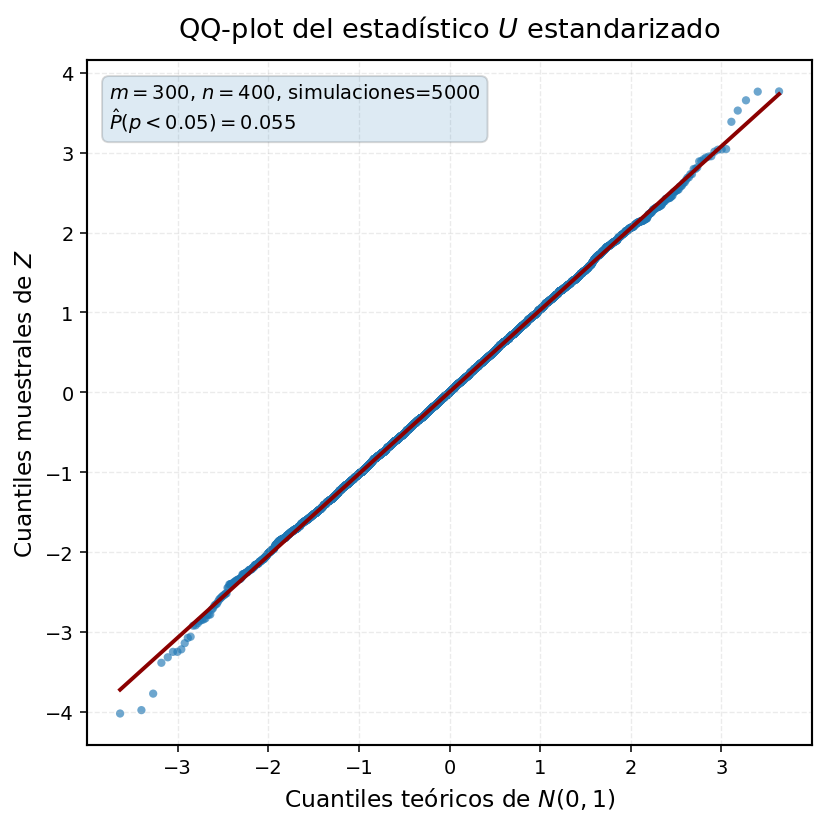

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --------------------------------------------------
# Configuración del experimento
# --------------------------------------------------
rng = np.random.default_rng(12345)

m = 300          # tamaño muestra X
n = 400          # tamaño muestra Y
B = 5000         # número de simulaciones

# --------------------------------------------------
# Simulación bajo H0: mismas distribuciones
# --------------------------------------------------
u_vals = np.empty(B)
z_vals = np.empty(B)
p_vals = np.empty(B)

for b in range(B):
    x = rng.normal(loc=0, scale=1, size=m)
    y = rng.normal(loc=0, scale=1, size=n)

    res = stats.mannwhitneyu(x, y, alternative='two-sided')
    u = res.statistic

    mu_u = m * n / 2
    sigma_u = np.sqrt(m * n * (m + n + 1) / 12)

    z = (u - mu_u) / sigma_u

    u_vals[b] = u
    z_vals[b] = z
    p_vals[b] = res.pvalue

print(f"Promedio U simulado: {u_vals.mean():.3f}")
print(f"Media teórica U:     {m*n/2:.3f}")
print(f"Promedio Z simulado: {z_vals.mean():.3f}")
print(f"Desv. Z simulada:    {z_vals.std(ddof=1):.3f}")
print(f"Proporción p<0.05:   {(p_vals < 0.05).mean():.3f}")

# --------------------------------------------------
# QQ-plot de Z vs Normal(0,1)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6), dpi=140)

(osm, osr), (slope, intercept, r) = stats.probplot(z_vals, dist="norm")

# Recta de referencia
xline = np.linspace(np.min(osm), np.max(osm), 200)
ax.plot(
    xline,
    slope * xline + intercept,
    linewidth=2,
    color="darkred"
)

# Puntos
ax.scatter(
    osm, osr,
    s=18,
    alpha=0.65,
    edgecolors="none"
)

# Estética
ax.set_title("QQ-plot del estadístico $U$ estandarizado", fontsize=14, pad=12)
ax.set_xlabel("Cuantiles teóricos de $N(0,1)$", fontsize=12)
ax.set_ylabel("Cuantiles muestrales de $Z$", fontsize=12)
ax.grid(alpha=0.25, linestyle="--", linewidth=0.7)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

ax.tick_params(axis='both', labelsize=10)

# Texto informativo
texto = (
    f"$m={m}$, $n={n}$, simulaciones={B}\n"
    #f"$\\bar Z={z_vals.mean():.3f}$, $s_Z={z_vals.std(ddof=1):.3f}$\n"
    f"$\\hat P(p<0.05)={(p_vals < 0.05).mean():.3f}$"
)
ax.text(
    0.03, 0.97, texto,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
)

plt.tight_layout()
plt.show()

## Graficas adicionales para entender la muesta del escenario 7

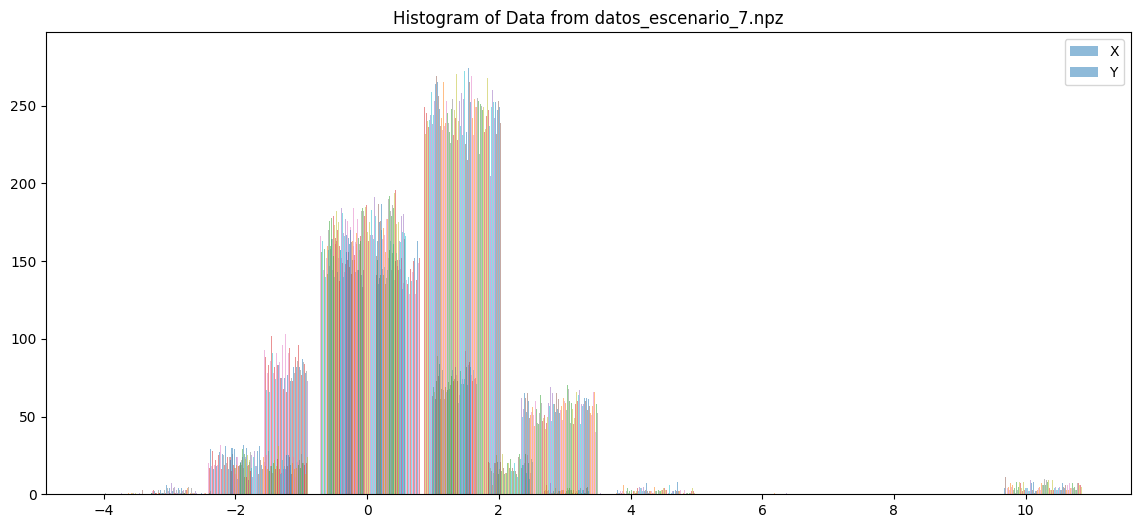

In [2]:
data = np.load('./../data/datos_escenario_7.npz')
# Assuming the .npz file contains arrays, e.g., 'x' and 'y'; adjust keys as needed
plt.figure(figsize=(14, 6))
plt.hist(data['x'], alpha=0.5, label='X')
plt.hist(data['y'], alpha=0.5, label='Y')
plt.legend()
plt.title('Histogram of Data from datos_escenario_7.npz')
plt.show()

500


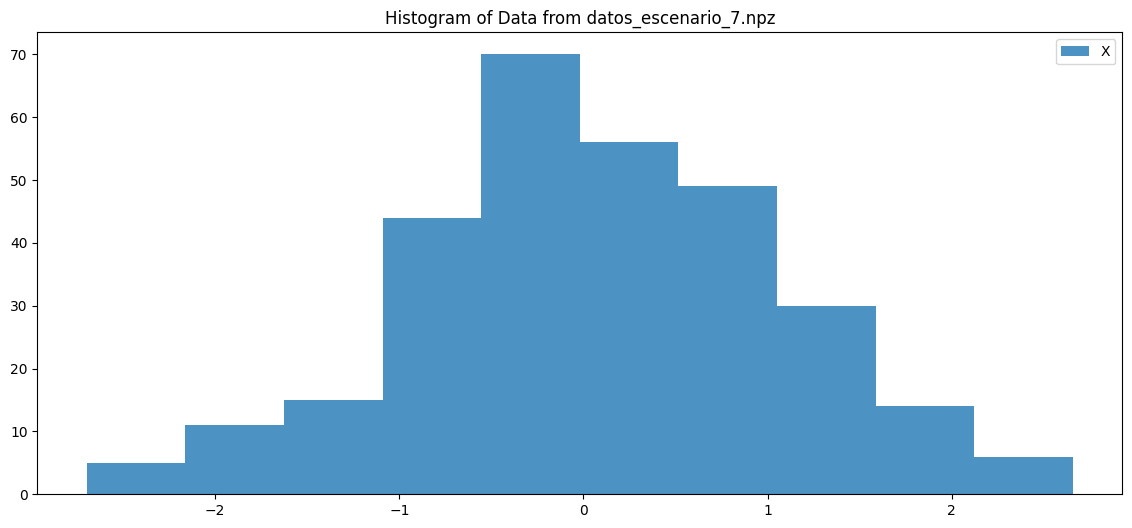

In [3]:
data = np.load('./../data/datos_escenario_7.npz')
# Assuming the .npz file contains arrays, e.g., 'x' and 'y'; adjust keys as needed
plt.figure(figsize=(14, 6))
print(len(data['x']))
plt.hist(data['x'][0], alpha=0.8, label='X')
plt.legend()
plt.title('Histogram of Data from datos_escenario_7.npz')
plt.show()

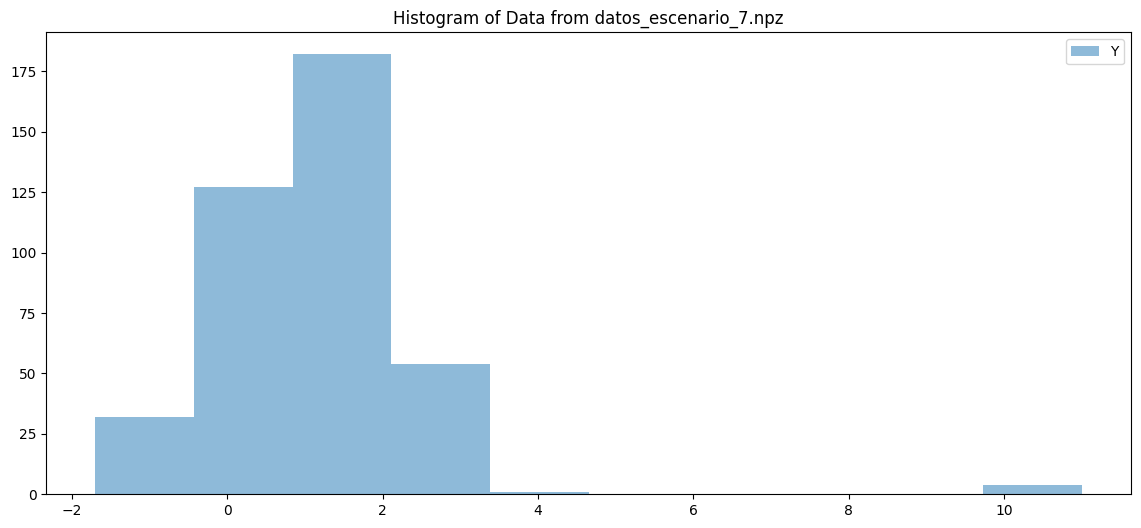

In [4]:
data = np.load('./../data/datos_escenario_7.npz')
# Assuming the .npz file contains arrays, e.g., 'x' and 'y'; adjust keys as needed
plt.figure(figsize=(14, 6))
plt.hist(data['y'][0], alpha=0.5, label='Y')
plt.legend()
plt.title('Histogram of Data from datos_escenario_7.npz')
plt.show()

In [5]:
import numpy as np

m = 300
n = 400

EU = m * n / 2
VarU = m * n * (m + n + 1) / 12
print(f"Esperanza de U: {EU:.3f}")
print(f"Varianza de U: {VarU:.3f}")
print(f"Desvacion estandar de U: {np.sqrt(VarU):.6f}")

Esperanza de U: 60000.000
Varianza de U: 7010000.000
Desvacion estandar de U: 2647.640459


In [6]:
print(2647.64*2647.64)

7009997.569599999
